In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pen's Code

Importing Data

In [108]:
DF_visit = pd.read_csv('Visit data.csv') #visitor data from 2015-2024
DF_econ = pd.read_csv("Economic data.csv") #economic data from 2015-2024
states = pd.read_csv("states.csv") #regional breakdown of states
states = states.drop(columns = "State") #Removing column to make merging easier later
longlat_bad = pd.read_csv("df_2.csv") #Location data for the national parks

Cleaning and wrangling Visitor Data

In [109]:
DF_visit.head()
DF_visit["State"] = DF_visit["State"].str.strip() # Maine (ME) had an extra space, which caused problems later

In [110]:
DF_visit['Month_Num'] = pd.to_datetime(DF_visit['Month'], format='%B').dt.month
DF_visit['Date'] = pd.to_datetime(DF_visit.Year.astype(str) + '/' + DF_visit.Month_Num.astype(str) + '/01') #making date-time for time series visualizations

DF_visit["Join Code"] = DF_visit["Park Code"] + DF_visit["Year"].astype(str) #combining year and park code

In [111]:
DF_visit = pd.merge(DF_visit, states, left_on = "State", right_on = "State Code",how = "left" ) #merging visitor data with regional state breakdown

In [112]:
DF_visit = DF_visit.drop(columns = "State Code") #duplicate column

#To make merging with location data set easier
DF_visit["Park Name"] = DF_visit["Park Name"].str.replace(" NP", " National Park")
DF_visit["Park Name Only"] = DF_visit["Park Name"].str.split(" National Park").str[0]
DF_visit["Park Name Only"] = DF_visit["Park Name Only"].str.split(" &").str[0]
DF_visit["Park Name Only"] = DF_visit["Park Name Only"].str.replace("Hawaii", "Hawaiʻi")
DF_visit["Park Name Only"] = DF_visit["Park Name Only"].str.strip()

Visitor Data by year instead of month

In [113]:
#making a dictionary for how to handle columns when summing months in a year

keys_bad = DF_visit.columns.tolist()
to_remove = ["Month","Month_Num","Date"]
keys= list(filter(lambda x: x not in to_remove, keys_bad))

values = ["first","first","first","first","sum","sum","sum","sum","sum","sum","sum","sum","sum","sum","sum","sum","first","first","first","first"]

agg_list = dict(zip(keys,values))

In [114]:
DF_visit_by_year = DF_visit.groupby(by=["Park Code","Year"]).agg(agg_list)

Cleaning Economic Data

In [115]:
DF_econ["Join Code"] = DF_econ["Code"] + DF_econ["Year"].astype(str) # to make merging easier
DF_econ = DF_econ.drop(columns= ["Year","Code"]) #getting rid of duplicate columns

Merging visitor and economic data

In [116]:
DF_all = pd.merge(DF_visit_by_year, DF_econ, on = "Join Code")
DF_all = DF_all.drop(columns= ["Name", "Recreation Visits"]) #Dropping duplicate columns

Location Data cleaning and wrangling

In [117]:
longlat_mid = longlat_bad.drop(columns = [ "Unnamed: 0","Image", "Description"]) #Dropping irrelevant columns
longlat = longlat_mid.drop([1,37,44], axis = 0) #dropping rows that didnt matter to us

longlat["Name"] = longlat["Name"].str.replace('Wrangell–St.\xa0Elias ', "Wrangell - St. Elias") #name replacing for merge
longlat["Name"] = longlat["Name"].str.strip()

#Extracting longitude and latitude from Location column
longlat["LongLat"] = longlat["Location"].str.split("/").str[1]
longlat["LAT"] = longlat["LongLat"].str.split("°").str[0]
longlat["LAT"] = longlat["LAT"].str.split("\ufeff").str[1]
longlat["LONG"] = longlat["LongLat"].str.split("°N ").str[1].str.split("°W").str[0]
longlat["LONG"] = "-" + longlat["LONG"]
longlat["LONG"] = longlat["LONG"].astype(float)
longlat["LAT"] = longlat["LAT"].astype(float)

longlat = longlat.drop(columns = ["LongLat", "Location", "Recreation visitors (2021)[11]"]) #dropping duplicate columns

Adding location to datasets

In [118]:
Visit_longlat = pd.merge(DF_visit, longlat, left_on = "Park Name Only", right_on= "Name", how = "left") #merging visitor and location data
Visit_econ_longlat = pd.merge(DF_all, longlat, left_on = "Park Name Only", right_on= "Name", how = "left") #merging visitor and economic data with location data

Exporting

In [119]:
Visit_longlat.to_csv("Visit Location Data.csv")
Visit_econ_longlat.to_csv("Visit Econ Location Data.csv")

# Jasmine's Code

## Merging Datasets

In [120]:
visits = pd.read_csv('Visit Data.csv')

In [121]:
economics = pd.read_csv("Economic Data.csv")

In [122]:
## grouping visits by the year and park 

byYearPark = visits.groupby(by=["Year","Park Name", 'Park Code','State']).sum().reset_index()
byYearPark = byYearPark.drop(columns=['Month'])
byYearPark = byYearPark[byYearPark['Year']<2025]
#byYearPark.head()

In [123]:
## merging visits and economics together + getting rid of some extra columns 
visits_economics = pd.merge(byYearPark, economics, left_on=['Year', 'Park Code'], right_on=['Year', 'Code'], how='inner')
visits_economics = visits_economics.drop(columns = ["Name", "Recreation Visits", "Code"])

In [124]:
visits_economics.head()

,Year,Park Name,Park Code,State,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,...,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays,Visitor\nSpending,Jobs Supported,Labor Income,Value Added,Economic\nOutput
0,2015,Acadia National Park,ACAD,ME,2811184,47100,14452151,47100,0,135000,...,0,1233,8343,0,176670.0,"$247,910.80","3,878","$102,112.70","$172,526.10","$304,623.50"
1,2015,Arches National Park,ARCH,UT,1399247,0,5420170,0,0,27158,...,0,1208,6005,0,50933.0,"$162,718.20","2,711","$67,949.50","$122,729.00","$216,319.60"
2,2015,Badlands National Park,BADL,SD,989354,65911,4531214,32956,9474,4627,...,39444,1445,215,0,56062.0,"$62,209.20","1,015","$24,363.70","$40,138.30","$77,537.90"
3,2015,Big Bend National Park,BIBE,TX,381747,2364,9504644,7092,50747,53963,...,9643,32435,33945,0,205153.0,"$33,426.30",503,"$11,340.10","$20,658.10","$37,168.80"
4,2015,Biscayne National Park,BISC,FL,508164,0,1672449,0,0,1860,...,0,0,4305,0,6165.0,"$31,927.30",450,"$17,612.10","$27,499.20","$44,346.60"


In [125]:
visits_economics['State'].unique()

array(['ME ', 'UT', 'SD', 'TX', 'FL', 'CO', 'NM', 'CA', 'SC', 'OR', 'OH',
       'AK', 'MO', 'MT', 'AZ', 'WY', 'NV', 'TN/NC', 'HI', 'AR', 'IN',
       'MI', 'KY', 'WA', 'VA', 'ND', 'VI', 'MN'], dtype=object)

## EDA

### Summary statistics 

In [126]:
visits_economics.describe()

,Year,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,RV Campers,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays
count,600.000000,6.000000e+02,6.000000e+02,6.000000e+02,6.000000e+02,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,6.000000e+02
mean,2019.500000,1.412268e+06,3.957252e+05,1.146075e+07,2.654515e+05,43075.733333,38985.461667,24215.833333,17556.211667,22607.528333,7796.353333,450.735000,1.539616e+05
std,2.874678,1.946318e+06,1.465275e+06,1.982571e+07,8.673624e+05,131819.308223,69691.341451,42701.273377,78471.395285,48376.570396,15154.846949,1712.680532,2.914938e+05
min,2015.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,2017.000000,2.720400e+05,0.000000e+00,1.390753e+06,0.000000e+00,0.000000,0.000000,0.000000,0.000000,382.500000,0.000000,0.000000,9.645250e+03
50%,2019.500000,6.659130e+05,7.650500e+03,3.675749e+06,1.577800e+04,0.000000,6184.500000,3752.500000,0.000000,3525.000000,824.500000,0.000000,4.233600e+04
75%,2022.000000,1.704201e+06,6.363475e+04,1.093750e+07,8.404750e+04,18488.750000,49748.500000,29430.000000,0.000000,27069.500000,8300.250000,0.000000,1.550908e+05
max,2024.000000,1.416155e+07,1.123478e+07,1.035739e+08,5.617391e+06,938418.000000,588701.000000,376744.000000,616089.000000,337790.000000,89472.000000,12925.000000,2.062671e+06


In [127]:
visits.describe()

,Year,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,RV Campers,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays
count,7920.000000,7.920000e+03,7.920000e+03,7.920000e+03,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7788.000000
mean,2020.000000,1.183488e+05,3.309108e+04,9.550774e+05,22233.509091,3622.548359,3232.742424,2031.939141,1477.166288,1858.321465,652.305177,36.792045,13067.642655
std,3.162477,2.011076e+05,1.264970e+05,2.170515e+06,77496.278277,14044.597612,8441.268642,5061.824709,10890.371389,5461.584677,1637.493130,185.225800,34406.059026
min,2015.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,1.072150e+04,0.000000e+00,5.204350e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000
50%,2020.000000,4.537750e+04,4.460000e+02,1.931590e+05,600.000000,0.000000,46.000000,0.000000,0.000000,84.000000,0.000000,0.000000,1375.500000
75%,2023.000000,1.282242e+05,5.797750e+03,7.211620e+05,6150.000000,897.250000,1852.500000,1520.000000,0.000000,675.000000,335.000000,0.000000,9480.500000
max,2025.000000,1.739720e+06,1.334690e+06,2.021239e+07,685776.000000,153527.000000,121937.000000,78060.000000,163452.000000,62848.000000,14436.000000,6165.000000,360221.000000


### Top 5 Years with most recreation visitors 

In [128]:
visits.groupby(by='Year').sum().drop(columns =["Month", "Park Name", "Park Code","State"]).sort_values('Recreation Visitors', ascending = False).head()

,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,RV Campers,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays
Year,,,,,,,,,,,,
2024,91186076,24624441,689328121,16946841,2934501,2319208,1625650,1049104,1291922,505069,31513,9774561.0
2025,89961848,24646266,687763596,16818501,2845143,2212043,1563458,1165430,1153389,488445,20952,9393865.0
2023,89671691,24507664,704825539,16908622,2605545,2138044,1509415,1025902,1323345,518283,29331,9095365.0
2021,89614755,22200135,693100034,15347671,2081419,2063240,1374656,1025340,1512831,415743,24156,8438590.0
2019,88726379,24018185,731746982,15893952,2909336,2509363,1486627,973338,1292999,444026,21449,9580719.0


### Top 5 Parks with most recreation visitors 

In [129]:
top_5_parks=visits_economics.groupby('Park Name').agg({'Recreation Visitors':'mean', 'Economic\nOutput':'mean','Jobs Supported':'mean'})
top_5_parks =top_5_parks.sort_values('Recreation Visitors', ascending = False)
top_5_parks=top_5_parks.head()
top_5_parks



TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
top_5_eco =  visits_economics[visits_economics['Park Name'].isin(['Great Smoky Mountains National Park', 'Grand Canyon National Park','Zion National Park	', 'Rocky Mountain National Park','Yellowstone National Park' ])]

### Top 5 parks with the most Jobs Supported

In [ ]:
top_5_parks_jobs = visits_economics[visits_economics['Park Name'].isin(['Great Smoky Mountains National Park', 'Grand Canyon National Park', 'Grand Teton National Park','Yellowstone National Park', 'Yosemite National Park'])]
top_5_parks_jobs

,Year,Park Name,Park Code,State,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,...,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays,Visitor\nSpending ($),Jobs Supported,Labor Income ($),Value Added ($),Economic\nOutput ($)
23,2015,Grand Canyon National Park,GRCA,AZ,5520736,62876,87141657,62876,540000,207490,...,25289,293866,32709,0,1200582,584890.9,8897.0,301914.6,502940.4,813705.8
24,2015,Grand Teton National Park,GRTE,WY,3149921,1497965,21758918,1497965,210538,0,...,385770,33798,1132,0,631240,560394.4,8862.0,258250.2,412894.3,728987.8
27,2015,Great Smoky Mountains National Park,GRSM,TN/NC,10712674,11234780,79442309,5617391,11186,172984,...,0,97629,26918,0,425892,873886.5,13709.0,396249.7,692101.0,1181331.9
57,2015,Yellowstone National Park,YELL,WY,4097710,1156118,82016845,711795,552940,104149,...,584979,44898,11715,0,1368514,493620.9,7737.0,224826.5,361876.3,638574.7
58,2015,Yosemite National Park,YOSE,CA,4150217,155081,78505877,3993223,938418,588701,...,0,211966,39214,0,2062671,449080.8,6887.0,207730.7,348826.2,593693.7
83,2016,Grand Canyon National Park,GRCA,AZ,5969811,60435,94286572,60435,600307,206626,...,24257,330703,40891,0,1291386,648170.9,9779.0,334219.8,556633.8,904315.7
84,2016,Grand Teton National Park,GRTE,WY,3270076,1552896,20161755,1552896,196577,0,...,297084,36206,979,0,530846,597290.5,9365.0,274744.8,439366.4,779479.8
87,2016,Great Smoky Mountains National Park,GRSM,TN/NC,11312786,11215231,83859719,5607616,11493,190574,...,0,109349,24777,0,447876,942731.8,14673.0,426908.8,745508.1,1277787.6
117,2016,Yellowstone National Park,YELL,WY,4257177,1198856,84411927,743728,579227,101639,...,583068,44663,10986,0,1388575,524319.8,8156.0,238536.4,383908.1,680381.8
118,2016,Yosemite National Park,YOSE,CA,5028868,188246,77763403,4771376,743546,490431,...,0,216989,51542,0,1879252,520629.1,7883.0,238955.1,401329.8,686339.5


,Year,Park Name,Park Code,State,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,...,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays,Visitor\nSpending ($),Jobs Supported,Labor Income ($),Value Added ($),Economic\nOutput ($)
23,2015,Grand Canyon National Park,GRCA,AZ,5520736,62876,87141657,62876,540000,207490,...,25289,293866,32709,0,1200582,584890.9,8897.0,301914.6,502940.4,813705.8
27,2015,Great Smoky Mountains National Park,GRSM,TN/NC,10712674,11234780,79442309,5617391,11186,172984,...,0,97629,26918,0,425892,873886.5,13709.0,396249.7,692101.0,1181331.9
47,2015,Rocky Mountain National Park,ROMO,CO,4155916,8750,28840877,26250,0,124254,...,0,46301,12604,0,244086,268391.4,4144.0,152167.6,246198.3,408311.0
57,2015,Yellowstone National Park,YELL,WY,4097710,1156118,82016845,711795,552940,104149,...,584979,44898,11715,0,1368514,493620.9,7737.0,224826.5,361876.3,638574.7
59,2015,Zion National Park,ZION,UT,3648846,21900,25028289,5475,82853,133528,...,0,24655,18962,0,333781,202198.4,2823.0,104418.6,172318.2,274562.8


### Great smoky Mountains Visits

In [ ]:
# filtering for GSM
GSM = visits_economics[visits['Park Name'].isin(['Great Smoky Mountains National Park'])]
GSM.head()


,Year,Park Name,Park Code,State,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,...,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays,Visitor\nSpending ($),Jobs Supported,Labor Income ($),Value Added ($),Economic\nOutput ($)
27,2015,Great Smoky Mountains National Park,GRSM,TN/NC,10712674,11234780,79442309,5617391,11186,172984,...,0,97629,26918,0,425892,873886.5,13709.0,396249.7,692101.0,1181331.9
87,2016,Great Smoky Mountains National Park,GRSM,TN/NC,11312786,11215231,83859719,5607616,11493,190574,...,0,109349,24777,0,447876,942731.8,14673.0,426908.8,745508.1,1277787.6
147,2017,Great Smoky Mountains National Park,GRSM,TN/NC,11338893,10396268,83343604,5198137,11160,160464,...,0,104352,22285,0,408357,922947.1,13942.0,405780.5,695842.3,1237735.0
207,2018,Great Smoky Mountains National Park,GRSM,TN/NC,11421200,10544377,83657339,5272190,11163,152167,...,0,97593,20105,0,394678,953130.0,13737.0,434943.0,743083.0,1288291.0
267,2019,Great Smoky Mountains National Park,GRSM,TN/NC,12547743,10544367,91203583,5272185,10955,155409,...,0,94569,18828,0,393300,1054815.0,15176.0,482218.0,824057.0,1427790.0


In [ ]:
# finding the mean values of the differnt visit types 
pd.pivot_table(GSM,values = ["Recreation Visitors","Non-Recreation Visitors","Concession Lodging","Tent Campers","RV Campers","Concession Camping","Backcountry Campers","Misc Campers","Non-Recreation Overnight Stays"], index = ["Park Name"], aggfunc="mean")


,Backcountry Campers,Concession Camping,Concession Lodging,Misc Campers,Non-Recreation Overnight Stays,Non-Recreation Visitors,RV Campers,Recreation Visitors,Tent Campers
Park Name,,,,,,,,,
Great Smoky Mountains National Park,95327.8,0.0,10607.3,24742.9,0.0,10711707.3,132650.2,12201767.8,179343.7


In [ ]:
# creating a new df with the visits 
GSM_visits = pd.DataFrame({"Visit type": ["Recreation Visitors","Non-Recreation Visitors","Concession Lodging","Tent Campers","RV Campers","Concession Camping","Backcountry Campers","Misc Campers","Non-Recreation Overnight Stays"], "Total": [12201767.8	,10711707.3, 10607.3, 179343.7, 132650.2, 0.0, 95327.8, 24742.9, 0.0]})	 
GSM_visits = GSM_visits.drop([0, 1, 8])
GSM_visits = GSM_visits.sort_values("Total", ascending = False)
GSM_visits


,Visit type,Total
3,Tent Campers,179343.7
4,RV Campers,132650.2
6,Backcountry Campers,95327.8
7,Misc Campers,24742.9
2,Concession Lodging,10607.3
5,Concession Camping,0.0


### GSM Economics

In [ ]:
pd.pivot_table(GSM,values = ["Visitor\nSpending ($)","Jobs Supported","Labor Income ($)","Value Added ($)","Economic\nOutput ($)"], index = ["Park Name"], aggfunc="mean")


,Economic\nOutput ($),Jobs Supported,Labor Income ($),Value Added ($),Visitor\nSpending ($)
Park Name,,,,,
Great Smoky Mountains National Park,1916503.65,19143.8,673434.7,1124212.54,1341456.64


### Top 5 states

In [ ]:
#finding the top 5 states with most economic output
visits_economics.groupby(['State']).agg({'Recreation Visitors':'mean', 'Economic\nOutput ($)':'mean'}).sort_values('Economic\nOutput ($)', ascending = False).head()


,Recreation Visitors,Economic\nOutput ($)
State,,
TN/NC,1.220177e+07,1.916504e+06
WY,3.773470e+06,7.628075e+05
ME,3.514865e+06,5.242401e+05
MT,2.846475e+06,4.402187e+05
AZ,2.235024e+06,3.643716e+05


In [ ]:
#filtering out those states
top_5_states = visits_economics[visits_economics['State'].isin(["TN/NC", "WY", "MT","AZ",'ME '])]
top_5_states = top_5_states.groupby(['State', 'Park Name'])["Economic\nOutput ($)"].mean().reset_index()
top_5_states = top_5_states.sort_values('State', ascending = False)
top_5_states

,State,Park Name,Economic\nOutput ($)
6,WY,Grand Teton National Park,829264.41
7,WY,Yellowstone National Park,696350.65
5,TN/NC,Great Smoky Mountains National Park,1916503.65
4,MT,Glacier National Park,440218.66
3,ME,Acadia National Park,524240.06
0,AZ,Grand Canyon National Park,955292.63
1,AZ,Petrified Forest National Park,44841.64
2,AZ,Saguaro National Park,92980.42


### Last 5 states 

In [ ]:
visits_economics.groupby(['State']).agg({'Recreation Visitors':'mean', 'Economic\nOutput ($)':'mean'}).sort_values('Economic\nOutput ($)', ascending = False).tail()


,Recreation Visitors,Economic\nOutput ($)
State,,
TX,333993.8,33929.21
MN,233752.7,24691.14
NV,141646.4,11383.59
SC,172749.7,11294.62
MI,23961.6,8204.54


In [ ]:
bottom_5_states = visits_economics[visits_economics['State'].isin(["TX", "MN", "NV","SC",'MI'])]
bottom_5_states = bottom_5_states.groupby(['State', 'Park Name'])["Economic\nOutput ($)"].mean().reset_index()
bottom_5_states = bottom_5_states.sort_values('State', ascending = False)
bottom_5_states

,State,Park Name,Economic\nOutput ($)
4,TX,Big Bend National Park,48088.65
5,TX,Guadalupe Mountains National Park,19769.77
3,SC,Congaree National Park,11294.62
2,NV,Great Basin National Park,11383.59
1,MN,Voyageurs National Park,24691.14
0,MI,Isle Royale National Park,8204.54


## Graphs

In [ ]:
# setting the theme 

sns.set_theme(palette='gist_earth')
sns.set_style("whitegrid")
sns.color_palette("gist_earth", 6)

[(0.09408431928011998, 0.25456763098682095, 0.4747997187719709),
 (0.19002743319550042, 0.5042304347826086, 0.49565724681625223),
 (0.25661406784936197, 0.5855013377926422, 0.32284437777281283),
 (0.5107321752862218, 0.6620551820728292, 0.32917535903993705),
 (0.724172627277075, 0.7035188948306594, 0.37379467833956326),
 (0.8342929845025828, 0.6922737254901962, 0.5786758598521377)]

Text(0.5, 1.0, 'National Parks with the Most Recreation Visits per Year')

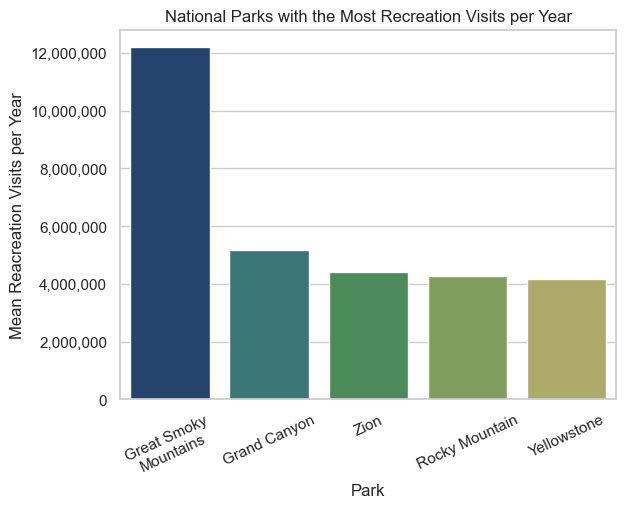

In [ ]:
 
plt1 = sns.barplot(data = top_5_parks, x='Park Name', y='Recreation Visitors', errorbar=None, hue = "Park Name")

# X axis 
plt1.set_xticks(range(5))
plt1.set_xticklabels(labels = ['Great Smoky\nMountains', "Grand Canyon", 'Zion','Rocky Mountain','Yellowstone'], rotation=25)

# Y axis
ticks = [0,2000000,4000000,6000000,8000000,10000000,12000000]
plt1.set_yticks(ticks)
plt1.set_yticklabels(["0", "2,000,000", "4,000,000", "6,000,000", "8,000,000", "10,000,000", "12,000,000"])

# Titles
plt1.set(xlabel='Park', ylabel='Mean Reacreation Visits per Year')
plt.title("National Parks with the Most Recreation Visits per Year")


Text(0.5, 1.0, 'Economic Output vs Recreation Visits')

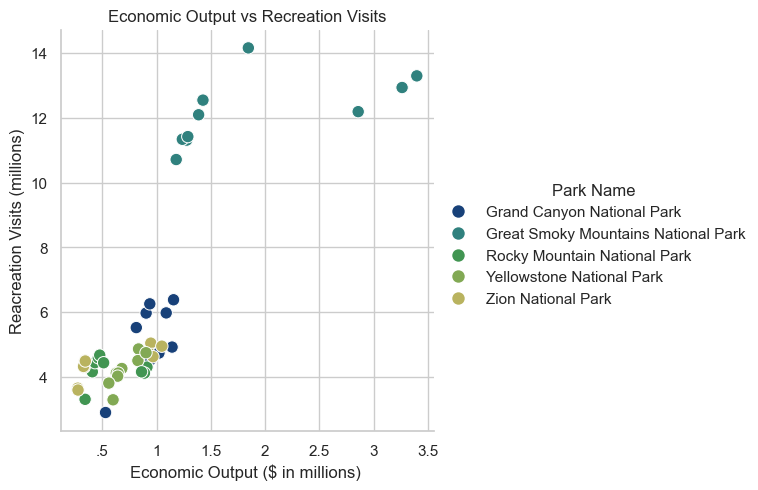

In [ ]:
plt2 = sns.relplot(data = top_5_eco, x='Economic\nOutput ($)', y='Recreation Visitors', hue = 'Park Name', s=80)

# X axis
ticksx = [500000, 1000000, 1500000, 2000000, 2500000, 3000000, 3500000]
xlabels = ['.5', '1', '1.5', '2', '2.5', '3', '3.5']
plt.xticks ( ticks=ticksx, labels=xlabels)


# Y axis
ticksy = [4000000, 6000000, 8000000, 10000000, 12000000, 14000000] 
ylabels = [4, 6, 8,10,12,14] 
plt.yticks ( ticks=ticksy, labels=ylabels)

#Titles
plt2.set(xlabel='Economic Output ($ in millions) ', ylabel='Reacreation Visits (millions)')
plt.title('Economic Output vs Recreation Visits')

Text(0.5, 1.0, 'Great Smokey Mountains Recreational Visit Types')

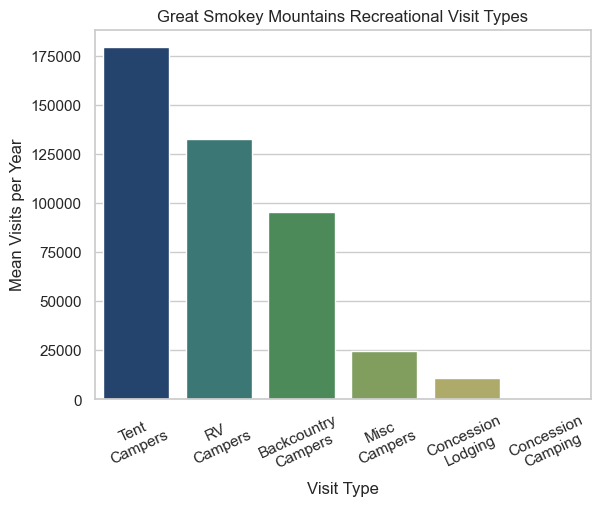

In [ ]:
plt3 = sns.barplot(data = GSM_visits, x='Visit type', y='Total', hue = 'Visit type', errorbar=None, palette='gist_earth')
sns.set_style("whitegrid")

# X axis
plt3.set_xticks(range(6))
plt3.set_xticklabels(labels = ['Tent\nCampers', 'RV\nCampers', 'Backcountry\nCampers', 'Misc\nCampers', 'Concession\nLodging','Concession\nCamping'], rotation=25)

# Titles
plt3.set(xlabel='Visit Type', ylabel='Mean Visits per Year')
plt.title("Great Smokey Mountains Recreational Visit Types")


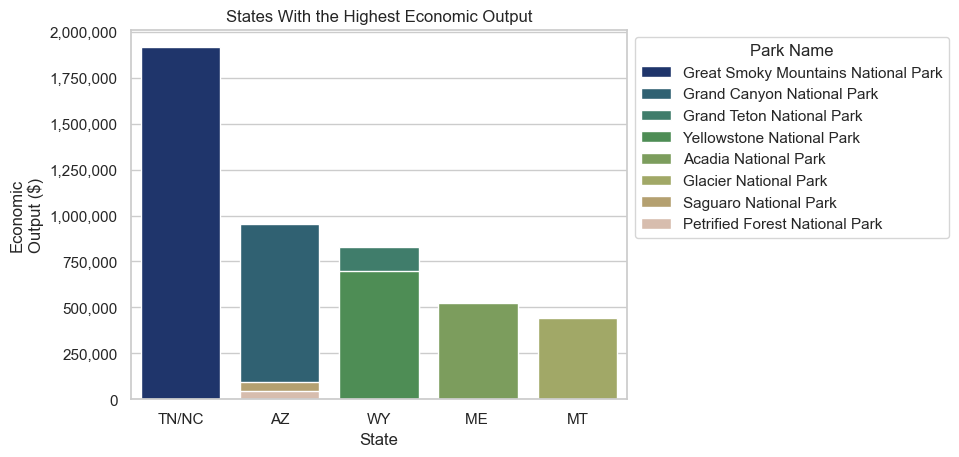

In [ ]:
# Sorting values
top_5_states = top_5_states.sort_values("Economic\nOutput ($)", ascending = False)

plt4 = sns.barplot(data=top_5_states, x = 'State', y = "Economic\nOutput ($)", errorbar=None, hue='Park Name', dodge = False,palette='gist_earth', legend = 'full')

#Y axis
ticks = [0,250000, 500000, 750000,1000000, 1250000,1500000,1750000,2000000]
plt4.set_yticks(ticks)
plt4.set_yticklabels(['0','250,000', '500,000', '750,000','1,000,000', '1,250,000','1,500,000','1,750,000','2,000,000'])

# Title + legend 
plt.title("States With the Highest Economic Output")
sns.move_legend(plt4, "upper left", bbox_to_anchor=(1, 1))


Text(0.5, 1.0, 'Parks With the Most Jobs Supported')

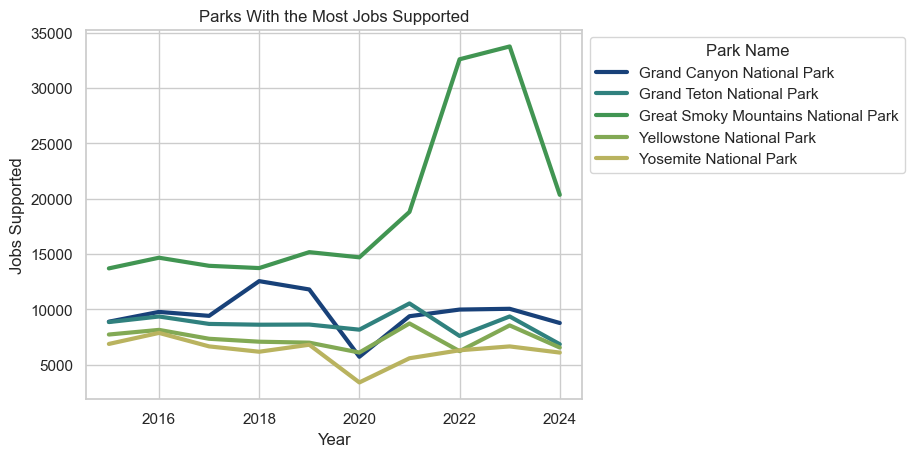

In [ ]:

plt5 = sns.lineplot(data = top_5_parks_jobs, x='Year', y='Jobs Supported', errorbar=None, hue = "Park Name", linewidth=3)

# Title + legend
sns.move_legend(plt5, "upper left", bbox_to_anchor=(1, 1))
plt.title("Parks With the Most Jobs Supported")



Text(0.5, 1.0, 'States With the Lowest Economic Output')

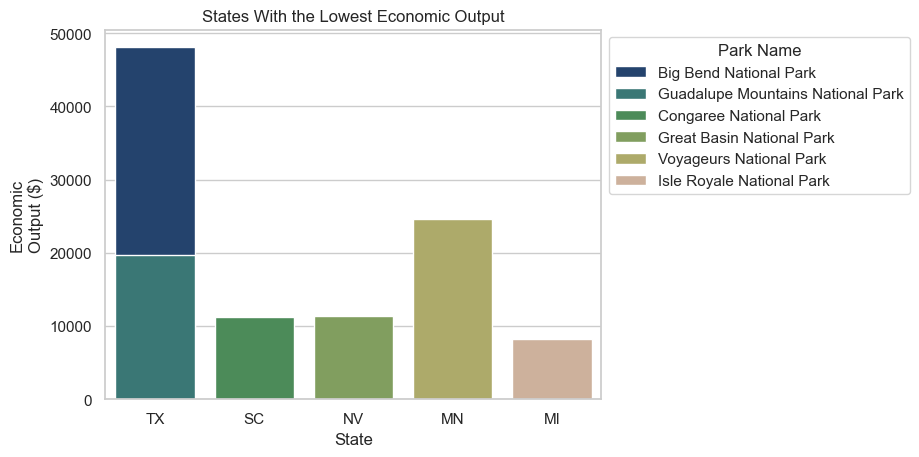

In [ ]:

plt6 = sns.barplot(data=bottom_5_states, x = 'State', y = "Economic\nOutput ($)", errorbar=None, hue='Park Name', dodge = False,palette='gist_earth', legend = 'full')

# Title + legend
sns.move_legend(plt6, "upper left", bbox_to_anchor=(1, 1))
plt.title("States With the Lowest Economic Output")

In [ ]:
#sns.pairplot(visits_economics, hue="Park Name")

# Addison's code

## Merging Datasets

In [ ]:
visits_df = pd.read_csv('/Users/addisonthompson/Desktop/Visit data.csv')

In [ ]:
economics = pd.read_csv('/Users/addisonthompson/Desktop/Economic data.csv')

In [ ]:
## grouping visits by the year and park 

byYearPark = visits_df.groupby(by=["Year","Park Name", 'Park Code','State']).sum().reset_index()
byYearPark = byYearPark.drop(columns=['Month'])
byYearPark = byYearPark[byYearPark['Year']<2025]

In [ ]:
## merging visits and economics together + getting rid of some extra columns 
visits_economics = pd.merge(byYearPark, economics, left_on=['Year', 'Park Code'], right_on=['Year', 'Code'], how='inner')
visits_economics = visits_economics.drop(columns = ["Name", "Recreation Visits", "Code"])

## COVID Time Series and EDA things

Looking to see if there is any noticible difference in visitation/economics during, before, and after COVID.

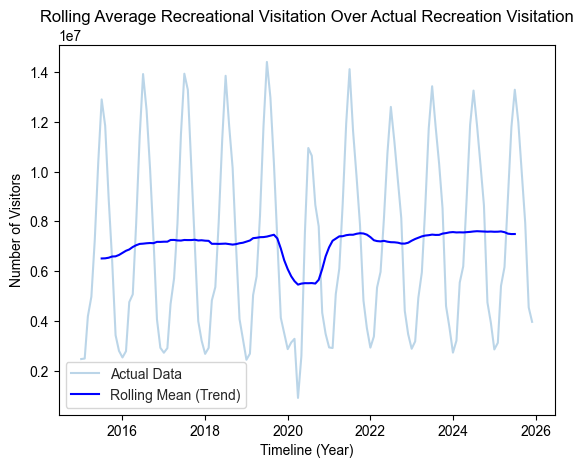

In [ ]:

months = {'January': 1, 
          'February': 2, 
          'March': 3, 
          'April': 4, 
          'May': 5, 
          'June': 6,
          'July': 7, 
          'August': 8, 
          'September': 9, 
          'October': 10, 
          'November': 11, 
          'December': 12}

visits_df['Date'] = pd.to_datetime(visits_df.assign(day=1).rename(columns={'Year':'year'})[['year', 'day']].assign(month=visits_df['Month'].map(months)))

monthly_data = visits_df.groupby('Date')['Recreation Visitors'].sum().reset_index()

# a rolling avg across the year
monthly_data['Trend'] = monthly_data['Recreation Visitors'].rolling(window=12, center=True).mean()

# plot of how visitation looks with an overlay of what the rolling avg is
plt.plot(monthly_data['Date'], monthly_data['Recreation Visitors'], alpha=0.3, label='Actual Data')
plt.plot(monthly_data['Date'], monthly_data['Trend'], label='Rolling Mean (Trend)', color='blue')
sns.set_style("whitegrid")

plt.title('Rolling Average Recreational Visitation Over Actual Recreation Visitation')
plt.xlabel('Timeline (Year)')
plt.ylabel('Number of Visitors')
plt.legend()



This shows the large dip in park visitation with the clousures from COVID and how noticible it is compared to other years.

Text(0, 0.5, 'Recreation Visitors')

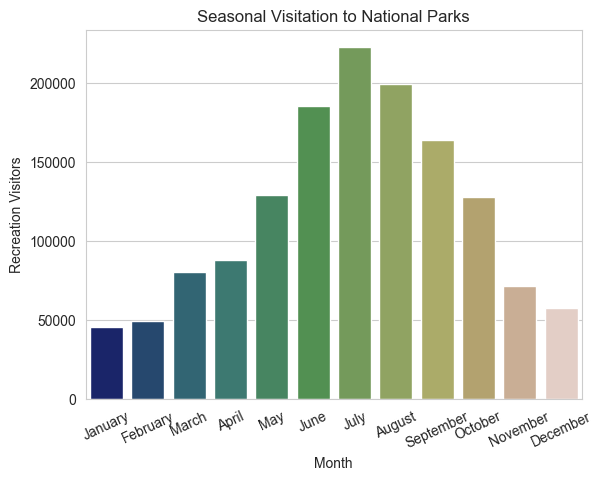

In [ ]:
fig, ax = plt.subplots()

# average visitors for each month across all years
seasonal_profile = visits_df.groupby('Month')['Recreation Visitors'].mean().reindex(months)

# Plot as a bar chart to show how visitation fluctuates across seasons
sns.barplot(x=seasonal_profile.index, y=seasonal_profile.values, hue=seasonal_profile.index, palette='gist_earth', legend = False)
ax.set_xticks(range(12))
ax.set_xticklabels(labels = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], rotation=25)
sns.set_style("whitegrid")

plt.title('Seasonal Visitation to National Parks')
plt.ylabel('Recreation Visitors') # x-axis has automatic label

shows that visitation is up during summer months, makes sense with work schedules along with weather

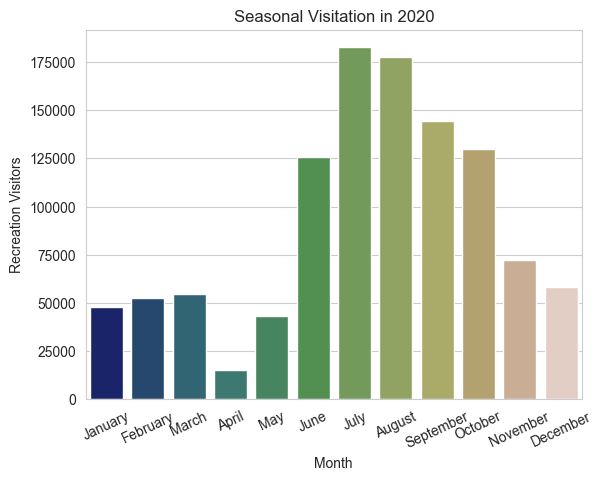

In [ ]:
df = visits_df

covid_2020 = df[df['Year'] == 2020] # getting just 2020

fig, ax = plt.subplots()

month_list = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}

monthly_totals = covid_2020.groupby('Month')['Recreation Visitors'].mean().reindex(month_list).reset_index()

# bar plot of just covid
sns.barplot(data=monthly_totals, x='Month', y='Recreation Visitors', hue='Month', legend = False, palette='gist_earth')

plt.title('Seasonal Visitation in 2020')

ax.set_xticks(range(12))
ax.set_xticklabels(labels = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], rotation=25)
sns.set_style("whitegrid")

plt.show()

compared to other seasonal graph before this one, shows how much covid closures affect visitation

Text(0.5, 1.0, '2019-2021 in Recreation Visitation')

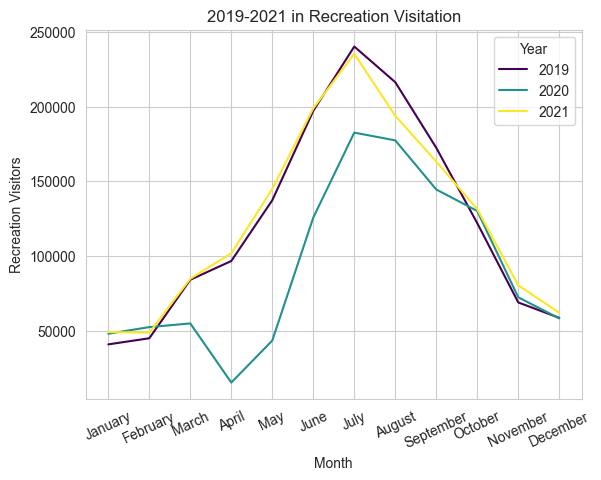

In [ ]:
comparison = df[df['Year'].isin([2019, 2020, 2021])] # getting 2019, 2020, and 2021

fig, ax = plt.subplots() # to be able to change axis

sns.lineplot(data=comparison, x='Month', y='Recreation Visitors', hue = 'Year', palette='viridis', errorbar=None) 
# addding errorbar=none to have no confidence interval and just show the number
ax.set_xticks(range(12))
ax.set_xticklabels(labels = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], rotation=25)

sns.set_style("whitegrid")

plt.title('2019-2021 in Recreation Visitation')

even when park closures where over, the number of visitors in 2020 is much lower due to travel limitations, limited number of visitors allowed into parks, and other factors happening simultaniously

# Jocelyn's code

In [ ]:
### CLEANING NATIONAL PARK AND MERGING ECONOMIC DATA 

In [ ]:
DF_visit = pd.read_csv('nationalparks.csv')
DF_econ = pd.read_csv("economics.csv")

In [ ]:
DF_visit.head()
DF_econ.head()

,Year,Code,Name,Recreation Visits,Visitor\nSpending,Jobs Supported,Labor Income,Value Added,Economic\nOutput
0,2024,ACAD,Acadia National Park,"3,961,661","$538,906","5,304","$243,133","$459,921","$744,545"
1,2024,ARCH,Arches National Park,"1,466,528","$287,785","2,502","$94,522","$183,289","$312,122"
2,2024,BADL,Badlands National Park,"1,094,245","$143,206","1,410","$58,901","$111,301","$191,413"
3,2024,BIBE,Big Bend National Park,"561,458","$56,817",585,"$17,269","$34,443","$63,707"
4,2024,BISC,Biscayne National Park,"512,213","$39,679",362,"$19,190","$34,520","$55,023"


In [ ]:
DF_visit['Month_Num'] = pd.to_datetime(DF_visit['Month'], format='%B').dt.month
DF_visit['Date'] = pd.to_datetime(DF_visit.Year.astype(str) + '/' + DF_visit.Month_Num.astype(str) + '/01')
DF_visit["Join Code"] = DF_visit["Park Code"] + DF_visit["Year"].astype(str)
DF_visit.head()


,Park Name,Park Code,State,Year,Month,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,RV Campers,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays,Month_Num,Date,Join Code
0,Crater Lake National Park,CRLA,OR,2015,January,10489,2100,39953,1050,0,0,0,0,162,0,0,162.0,1,2015-01-01,CRLA2015
1,Crater Lake National Park,CRLA,OR,2015,February,8635,2400,33682,1200,0,0,0,0,173,0,0,173.0,2,2015-02-01,CRLA2015
2,Crater Lake National Park,CRLA,OR,2015,March,13938,2800,54242,1400,0,0,0,0,273,0,0,273.0,3,2015-03-01,CRLA2015
3,Crater Lake National Park,CRLA,OR,2015,April,16918,4800,63625,2400,62,0,0,0,171,0,0,233.0,4,2015-04-01,CRLA2015
4,Crater Lake National Park,CRLA,OR,2015,May,48217,4900,274731,2450,3457,0,0,2309,224,0,0,5990.0,5,2015-05-01,CRLA2015


In [ ]:
DF_visit_by_year = DF_visit.groupby(["Park Code","Year"]).agg({"Park Name": "first", "State": "first","Recreation Visitors":"sum", "Non-Recreation Visitors":"sum","Recreation Visitor Hours":"sum", "Non-Recreation Hours":"sum", "Concession Lodging":"sum", "Tent Campers":"sum", "RV Campers":"sum", "Concession Camping":"sum","Backcountry Campers":"sum","Misc Campers":"sum", "Non-Recreation Overnight Stays":"sum", "Total Overnight Stays":"sum", "Join Code":"first"})
DF_visit_by_year.head()

Park Name State  Recreation Visitors  \
Park Code Year                                                    
ACAD      2015  Acadia National Park   ME               2811184   
          2016  Acadia National Park   ME               3303393   
          2017  Acadia National Park   ME               3509271   
          2018  Acadia National Park   ME               3537575   
          2019  Acadia National Park   ME               3437286   

                Non-Recreation Visitors  Recreation Visitor Hours  \
Park Code Year                                                      
ACAD      2015                    47100                  14452151   
          2016                    47100                  22698596   
          2017                    47100                  24014370   
          2018                    47100                  23613754   
          2019                    47100                  23195664   

                Non-Recreation Hours  Concession Lodging  Tent Campers  \
Park Code Year                                                           
ACAD      2015                 47100                   0        135000   
          2016                 47100                   0        152811   
          2017                 47100                   0        152586   
          2018                 47100                   0        144744   
          2019                 47100                   0        140985   

                RV Campers  Concession Camping  Backcountry Campers  \
Park Code Year                                                        
ACAD      2015       32094                   0                 1233   
          2016       46629                 977                 1324   
          2017       55812                1657                 1597   
          2018       58215                1364                 1472   
          2019       57696                1090                 1284   

                Misc Campers  Non-Recreation Overnight Stays  \
Park Code Year                                                 
ACAD      2015          8343                               0   
          2016          8563                               0   
          2017         10889                               0   
          2018         11698                               0   
          2019         11674                               0   

                Total Overnight Stays Join Code  
Park Code Year                                   
ACAD      2015               176670.0  ACAD2015  
          2016               210304.0  ACAD2016  
          2017               222541.0  ACAD2017  
          2018               217493.0  ACAD2018  
          2019               212729.0  ACAD2019

In [ ]:
DF_econ["Join Code"] = DF_econ["Code"] + DF_econ["Year"].astype(str)
DF_econ.head()

,Year,Code,Name,Recreation Visits,Visitor\nSpending,Jobs Supported,Labor Income,Value Added,Economic\nOutput,Join Code
0,2024,ACAD,Acadia National Park,"3,961,661","$538,906","5,304","$243,133","$459,921","$744,545",ACAD2024
1,2024,ARCH,Arches National Park,"1,466,528","$287,785","2,502","$94,522","$183,289","$312,122",ARCH2024
2,2024,BADL,Badlands National Park,"1,094,245","$143,206","1,410","$58,901","$111,301","$191,413",BADL2024
3,2024,BIBE,Big Bend National Park,"561,458","$56,817",585,"$17,269","$34,443","$63,707",BIBE2024
4,2024,BISC,Biscayne National Park,"512,213","$39,679",362,"$19,190","$34,520","$55,023",BISC2024


In [ ]:
DF_all = pd.merge(DF_visit_by_year, DF_econ, on = "Join Code")
DF_all.head()

,Park Name,State,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,RV Campers,Concession Camping,...,Join Code,Year,Code,Name,Recreation Visits,Visitor\nSpending,Jobs Supported,Labor Income,Value Added,Economic\nOutput
0,Acadia National Park,ME,2811184,47100,14452151,47100,0,135000,32094,0,...,ACAD2015,2015,ACAD,Acadia National Park,"2,811,184","$247,910.80","3,878","$102,112.70","$172,526.10","$304,623.50"
1,Acadia National Park,ME,3303393,47100,22698596,47100,0,152811,46629,977,...,ACAD2016,2016,ACAD,Acadia National Park,"3,303,394","$274,208.80","4,195","$111,087.10","$188,275.10","$332,786.30"
2,Acadia National Park,ME,3509271,47100,24014370,47100,0,152586,55812,1657,...,ACAD2017,2017,ACAD,Acadia National Park,"3,509,271","$284,459.80","4,163","$107,621.50","$185,248.30","$338,873.80"
3,Acadia National Park,ME,3537575,47100,23613754,47100,0,144744,58215,1364,...,ACAD2018,2018,ACAD,Acadia National Park,"3,537,575","$387,654","5,602","$171,668","$304,982","$521,454"
4,Acadia National Park,ME,3437286,47100,23195664,47100,0,140985,57696,1090,...,ACAD2019,2019,ACAD,Acadia National Park,"3,437,286","$379,517","5,474","$168,284","$298,961","$510,962"


In [ ]:
DF_all.to_csv("Visit Econ Data.csv")


In [ ]:
DF_all.columns = DF_all.columns.str.replace('\n', ' ').str.strip()

DF_all.to_csv("Visit Econ Data.csv", index=False)

In [ ]:
### COLUMNS fixed (check below) 

In [ ]:
print(DF_all.columns)

Index(['Park Name', 'State', 'Recreation Visitors', 'Non-Recreation Visitors',
       'Recreation Visitor Hours', 'Non-Recreation Hours',
       'Concession Lodging', 'Tent Campers', 'RV Campers',
       'Concession Camping', 'Backcountry Campers', 'Misc Campers',
       'Non-Recreation Overnight Stays', 'Total Overnight Stays', 'Join Code',
       'Year', 'Code', 'Name', 'Recreation Visits', 'Visitor Spending',
       'Jobs Supported', 'Labor Income', 'Value Added', 'Economic Output'],
      dtype='object')


In [ ]:
### all code below is to make yearly colummns for the bar plot and merge them to be able to subtract 2019 visitors from 2020 

In [ ]:

yearly = DF_all.groupby(["Park Name", "Year"])["Recreation Visitors"].sum().reset_index()


In [ ]:
y2019 = yearly[yearly["Year"] == 2019]
y2020 = yearly[yearly["Year"] == 2020]


In [ ]:
merged = pd.merge(y2019, y2020, on="Park Name", suffixes=("_2019", "_2020"))


In [ ]:
merged["drop"] = merged["Recreation Visitors_2019"] - merged["Recreation Visitors_2020"]


In [ ]:
top5 = merged.sort_values("drop", ascending=False).head(5)


In [ ]:
sns.set_theme(palette='gist_earth')

In [ ]:
sns.set_style("whitegrid")

In [ ]:
### plot was created to show an overview of the top 10 most affected NP affected by COVID-19 by the number of recreational visitors lost . 
### also take into account different NP have different policies 
### we can possibily think about BIG BEND in Texas where there was probably little to no regulations 
#### whereas larger more commonly visited parks like Grand Canyon and Yosemite would have more strict regulations 

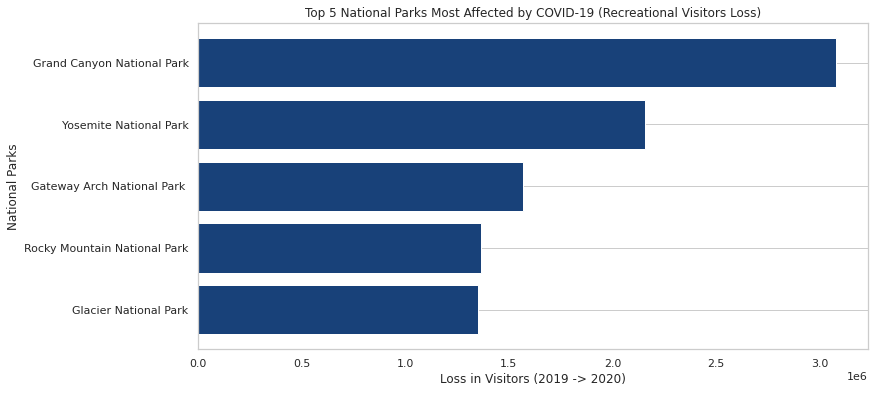

In [ ]:
plt.figure(figsize=(12, 6))


plt.barh(top5["Park Name"], top5["drop"])

plt.xlabel("Loss in Visitors (2019 -> 2020)")
plt.ylabel("National Parks")
plt.title("Top 5 National Parks Most Affected by COVID-19 (Recreational Visitors Loss)")

plt.gca().invert_yaxis()  # biggest at top
plt.grid(axis="x")

plt.show()

In [ ]:
#### side-by-side bar plots on NP visitations (2019 vs 2020 comparisons) 
### top 10 most affected not arranged but I could do that, I just don't think it really matters 

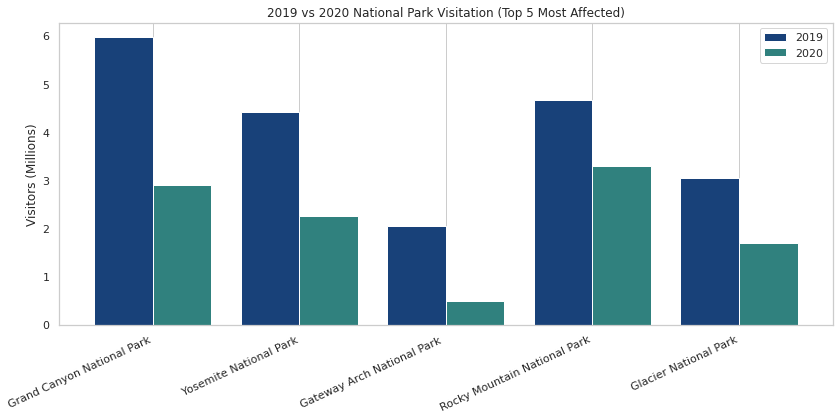

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to millions 
y2019 = top5["Recreation Visitors_2019"] / 1_000_000
y2020 = top5["Recreation Visitors_2020"] / 1_000_000

parks = top5["Park Name"]

x = np.arange(len(parks))
width = 0.4

plt.figure(figsize=(12, 6))

# Bars
plt.bar(x - width/2, y2019, width, label="2019")
plt.bar(x + width/2, y2020, width, label="2020")

# Labels and formatting 
plt.xticks(x, parks, rotation=25, ha="right")
plt.ylabel("Visitors (Millions)")
plt.title("2019 vs 2020 National Park Visitation (Top 5 Most Affected)")

plt.legend()
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [ ]:
### predictions for visitations for Grand Canyon and Economic Output 

In [ ]:
## economic outcomes if 2020 didn't happen (is there a difference?) 

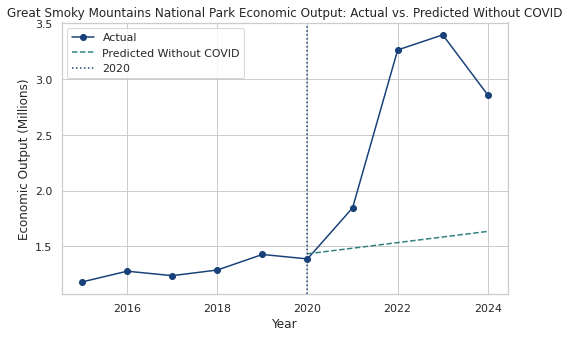

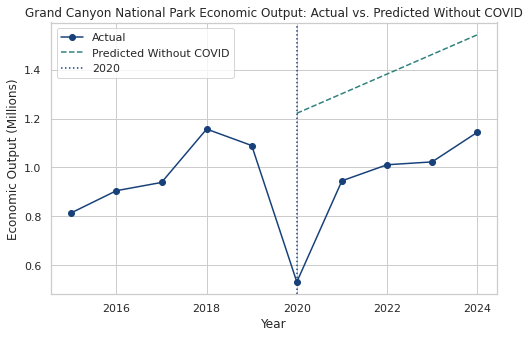

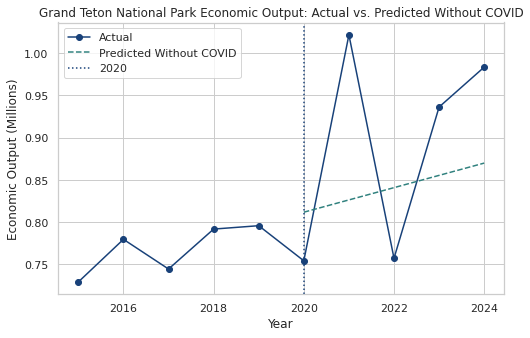

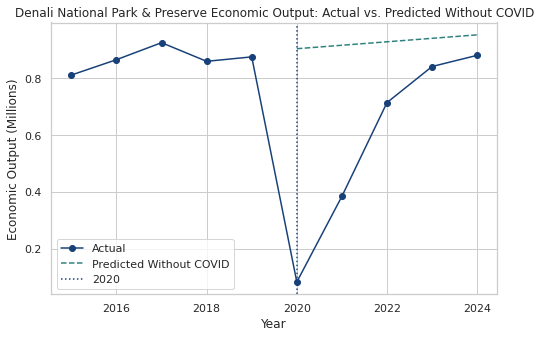

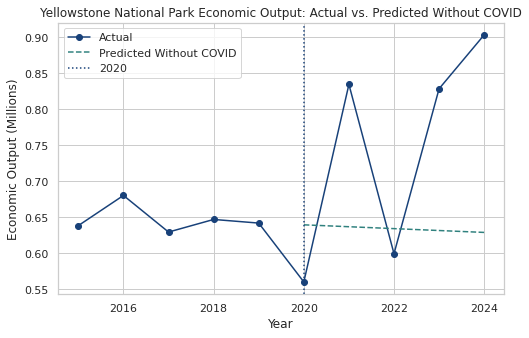

In [ ]:
for park in top5:
    park_data = econ_yearly[econ_yearly["Park Name"] == park].sort_values("Year")

    pre_covid = park_data[park_data["Year"] < 2020]
    covid_forward = park_data[park_data["Year"] >= 2020]

    x = park_data["Year"]
    y = park_data["Economic Output"]

    x_train = pre_covid["Year"]
    y_train = pre_covid["Economic Output"]

    # prediction based only on pre-COVID trend
    m, b = np.polyfit(x_train, y_train, 1)

    x_pred = covid_forward["Year"]
    y_pred = m * x_pred + b

    plt.figure(figsize=(8,5))

    # actual economic output
    plt.plot(x, y / 1_000_000, marker="o", label="Actual")

    # no-COVID prediction
    plt.plot(x_pred, y_pred / 1_000_000, linestyle="--", label="Predicted Without COVID")

    plt.axvline(2020, linestyle=":", label="2020")

    plt.title(f"{park} Economic Output: Actual vs. Predicted Without COVID")
    plt.xlabel("Year")
    plt.ylabel("Economic Output (Millions)")
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
### expected economic output based on data until 2050 

                             Park Name  Economic Output
0  Great Smoky Mountains National Park       19165036.5
1           Grand Canyon National Park        9552926.3
2            Grand Teton National Park        8292644.1
3      Denali National Park & Preserve        7231516.5
4            Yellowstone National Park        6963506.5


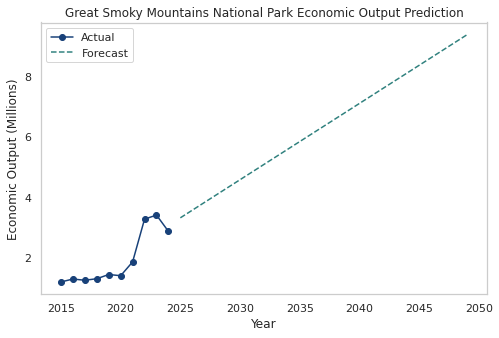

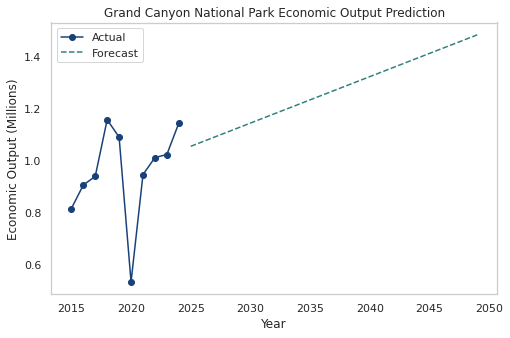

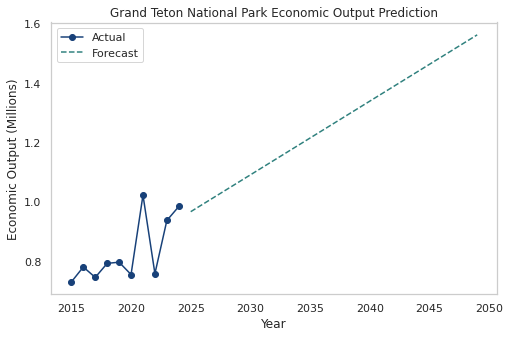

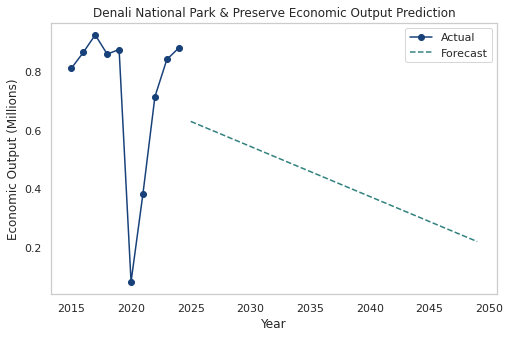

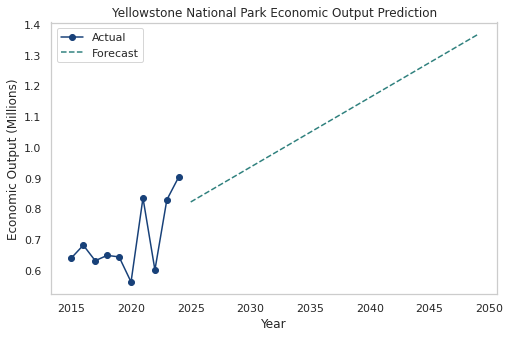

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DF_all["Economic Output"] = (
    DF_all["Economic Output"]
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

econ_yearly = (
    DF_all.groupby(["Park Name", "Year"])["Economic Output"]
    .sum()
    .reset_index()
)

top_econ = (
    econ_yearly.groupby("Park Name")["Economic Output"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

top5 = top_econ["Park Name"]

print(top_econ)

future_years = np.arange(
    econ_yearly["Year"].max() + 1,
    econ_yearly["Year"].max() + 26
)

for park in top5:
    park_data = econ_yearly[econ_yearly["Park Name"] == park]

    x = park_data["Year"]
    y = park_data["Economic Output"]

    m, b = np.polyfit(x, y, 1)

    future_pred = m * future_years + b

    plt.figure(figsize=(8,5))

    # actual
    plt.plot(x, y / 1_000_000, marker="o", label="Actual")

    # forecast
    plt.plot(future_years, future_pred / 1_000_000, linestyle="--", label="Forecast")

    plt.title(f"{park} Economic Output Prediction")
    plt.xlabel("Year")
    plt.ylabel("Economic Output (Millions)")
    plt.legend()
    plt.grid()

    plt.show()
